In [10]:
# 1. Imports
import pandas as pd
import numpy as np

# 2. Load the data
df = pd.read_csv("spam.csv", encoding="latin-1")

# 3. Initial Cleaning
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df.columns = ['Label', 'Message']
print("--- Dataset Ready ---")
display(df.head())

--- Dataset Ready ---


,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Total messages before cleaning: 5572
Total messages after removing duplicates: 5169



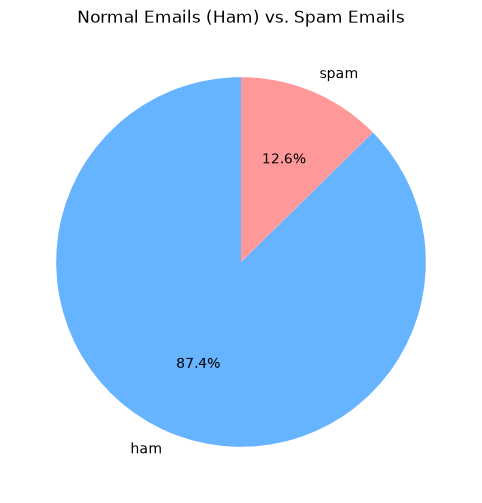

In [11]:
import matplotlib.pyplot as plt

# 4. Remove Duplicates
print(f"Total messages before cleaning: {len(df)}")
df = df.drop_duplicates(keep='first')
print(f"Total messages after removing duplicates: {len(df)}\n")

# 5. Visualize the Data
plt.figure(figsize=(6, 6))
# We count how many 'ham' and 'spam' labels there are, and plot them
df['Label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title('Normal Emails (Ham) vs. Spam Emails')
plt.ylabel('') # Hides the messy y-axis label
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# 6. Convert Labels to Numbers
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})

# 7. Hide the Answers (Train/Test Split)
X = df['Message']
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Translate Words into Math (Vectorization)
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print(f"Training data size: {X_train_vectorized.shape}")
print("Text successfully translated into numbers!")

Training data size: (4135, 7657)
Text successfully translated into numbers!


=== MODEL: NAIVE BAYES ===
Accuracy Score: 98.55%
Precision Score: 98.51%



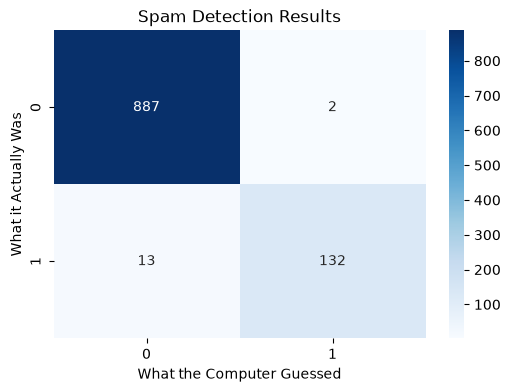

In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 9. Train the Algorithm
print("=== MODEL: NAIVE BAYES ===")
model = MultinomialNB()
model.fit(X_train_vectorized, y_train) # The machine studies the training data

# 10. Take the Final Exam
predictions = model.predict(X_test_vectorized)

# 11. Grade the Test
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)

print(f"Accuracy Score: {accuracy * 100:.2f}%")
print(f"Precision Score: {precision * 100:.2f}%\n")

# 12. Draw the Confusion Matrix (Visual Grading Rubric)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Spam Detection Results')
plt.xlabel('What the Computer Guessed')
plt.ylabel('What it Actually Was')
plt.show()

In [14]:
# 13. Test on Custom Messages
def test_message(text):
    text_vectorized = vectorizer.transform([text])
    result = model.predict(text_vectorized)[0]
    return "🚨 SPAM" if result == 1 else "✅ HAM (Normal)"

# Sample test messages
samples = [
    "Hey Aziz, are we still meeting tomorrow for coffee?",
    "CONGRATULATIONS! You won a $1000 Walmart gift card! Call now to claim your prize."
]

for msg in samples:
    print(f"Message: '{msg}'")
    print(f"Prediction: {test_message(msg)}\n")

Message: 'Hey Aziz, are we still meeting tomorrow for coffee?'
Prediction: ✅ HAM (Normal)

Message: 'CONGRATULATIONS! You won a $1000 Walmart gift card! Call now to claim your prize.'
Prediction: 🚨 SPAM

